# Spotify Dataset EDA (Standalone)

This notebook performs exploratory data analysis directly on the Spotify datasets
before integration.

Use this for:
- screenshots
- understanding dataset structure
- identifying data quality issues

In [8]:
import pandas as pd
import os
from pathlib import Path
import matplotlib.pyplot as plt

# Define paths
NOTEBOOK_DIR = os.getcwd()
PROJECT_ROOT = os.path.dirname(NOTEBOOK_DIR)
RAW_DATA_DIR = os.path.join(PROJECT_ROOT, "data", "raw")

print(f"Project Root: {PROJECT_ROOT}")
print(f"Raw Data Dir: {RAW_DATA_DIR}")


Project Root: /Users/rachel/Documents/School/Algonquin College/Business Intelligence/BI2/music-revival-streaming-analysis
Raw Data Dir: /Users/rachel/Documents/School/Algonquin College/Business Intelligence/BI2/music-revival-streaming-analysis/data/raw


In [9]:
def read_csv_safe(file_path):
    """
    Read CSV file with automatic encoding detection
    """
    encodings = ['utf-8', 'latin-1', 'iso-8859-1', 'cp1252', 'utf-16']
    
    for encoding in encodings:
        try:
            df = pd.read_csv(file_path, encoding=encoding)
            print(f"  ✓ Successfully read with encoding: {encoding}")
            return df
        except UnicodeDecodeError:
            continue
        except Exception as e:
            print(f"  Error with {encoding}: {e}")
            continue
    
    # If all fail, try with errors='ignore'
    print(f"  ⚠ Using fallback encoding with error handling")
    df = pd.read_csv(file_path, encoding='utf-8', errors='ignore')
    return df

print("✓ Safe CSV reader loaded")

✓ Safe CSV reader loaded


In [10]:
df1 = read_csv_safe(RAW_DATA_DIR + "/Popular_Spotify_Songs.csv" )
df2 = read_csv_safe(RAW_DATA_DIR + "/spotify_tracks.csv" )

print("Dataset 1 shape:", df1.shape)
print("Dataset 1 shape:", df2.shape)

  ✓ Successfully read with encoding: latin-1
  ✓ Successfully read with encoding: utf-8
Dataset 1 shape: (953, 24)
Dataset 1 shape: (6300, 8)


In [11]:
# Columns overview
print("Dataset 1 columns:")
print(df1.columns.tolist())

print("\nDataset 2 columns:")
print(df2.columns.tolist())

Dataset 1 columns:
['track_name', 'artist(s)_name', 'artist_count', 'released_year', 'released_month', 'released_day', 'in_spotify_playlists', 'in_spotify_charts', 'streams', 'in_apple_playlists', 'in_apple_charts', 'in_deezer_playlists', 'in_deezer_charts', 'in_shazam_charts', 'bpm', 'key', 'mode', 'danceability_%', 'valence_%', 'energy_%', 'acousticness_%', 'instrumentalness_%', 'liveness_%', 'speechiness_%']

Dataset 2 columns:
['id', 'name', 'genre', 'artists', 'album', 'popularity', 'duration_ms', 'explicit']


In [12]:
# Missing values
print("Dataset 1 missing values:")
print(df1.isna().sum())

print("\nDataset 2 missing values:")
print(df2.isna().sum())

Dataset 1 missing values:
track_name               0
artist(s)_name           0
artist_count             0
released_year            0
released_month           0
released_day             0
in_spotify_playlists     0
in_spotify_charts        0
streams                  0
in_apple_playlists       0
in_apple_charts          0
in_deezer_playlists      0
in_deezer_charts         0
in_shazam_charts        50
bpm                      0
key                     95
mode                     0
danceability_%           0
valence_%                0
energy_%                 0
acousticness_%           0
instrumentalness_%       0
liveness_%               0
speechiness_%            0
dtype: int64

Dataset 2 missing values:
id             0
name           0
genre          0
artists        0
album          0
popularity     0
duration_ms    0
explicit       0
dtype: int64


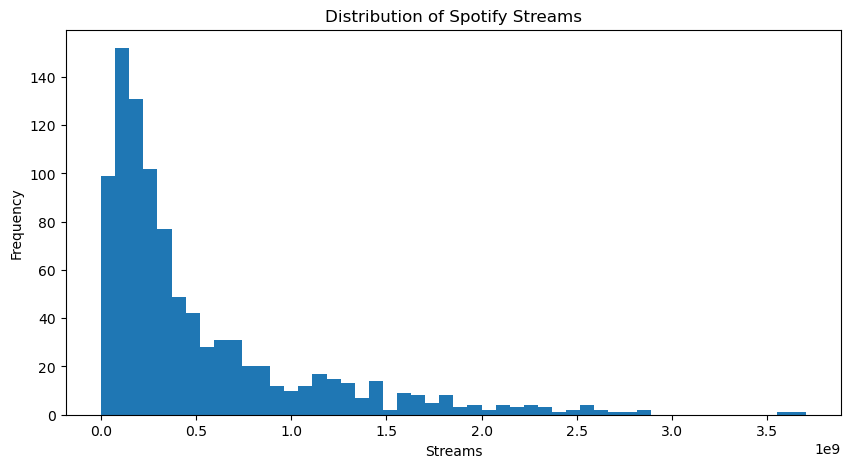

In [13]:
# Streams distribution
df1["streams"] = pd.to_numeric(df1["streams"], errors="coerce")

plt.hist(df1["streams"].dropna(), bins=50)
plt.title("Distribution of Spotify Streams")
plt.xlabel("Streams")
plt.ylabel("Frequency")
plt.show()

In [14]:
# Top tracks by streams
df1.sort_values("streams", ascending=False)[["track_name","artist(s)_name","streams"]].head(10)

,track_name,artist(s)_name,streams
55,Blinding Lights,The Weeknd,3.703895e+09
179,Shape of You,Ed Sheeran,3.562544e+09
86,Someone You Loved,Lewis Capaldi,2.887242e+09
620,Dance Monkey,Tones and I,2.864792e+09
41,Sunflower - Spider-Man: Into the Spider-Verse,"Post Malone, Swae Lee",2.808097e+09
162,One Dance,"Drake, WizKid, Kyla",2.713922e+09
84,STAY (with Justin Bieber),"Justin Bieber, The Kid Laroi",2.665344e+09
140,Believer,Imagine Dragons,2.594040e+09
725,Closer,"The Chainsmokers, Halsey",2.591224e+09
48,Starboy,"The Weeknd, Daft Punk",2.565530e+09


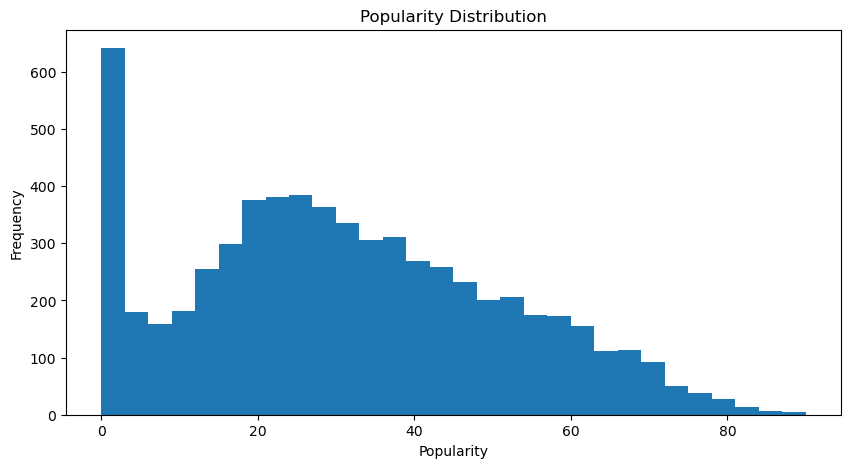

In [15]:
# Popularity distribution
plt.hist(df2["popularity"].dropna(), bins=30)
plt.title("Popularity Distribution")
plt.xlabel("Popularity")
plt.ylabel("Frequency")
plt.show()

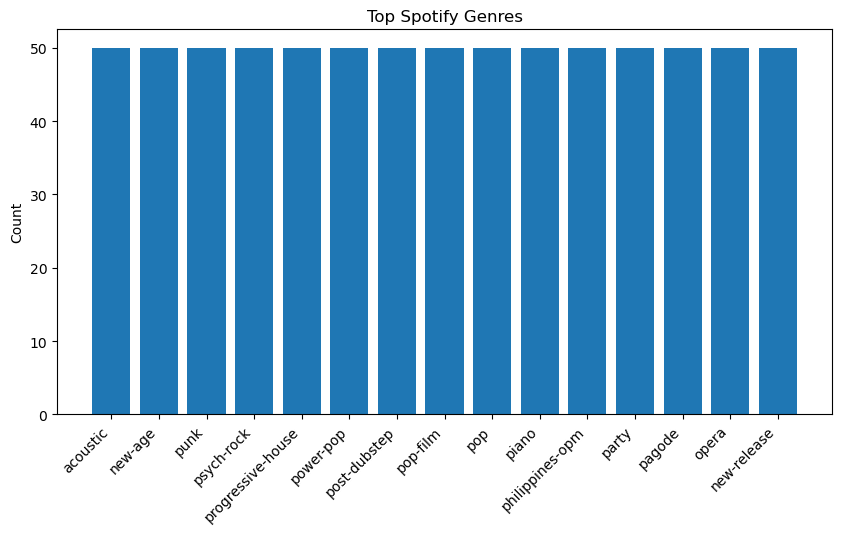

In [16]:
# Genre distribution
genre_counts = df2["genre"].value_counts().head(15)

plt.bar(genre_counts.index, genre_counts.values)
plt.xticks(rotation=45, ha="right")
plt.title("Top Spotify Genres")
plt.ylabel("Count")
plt.show()

In [17]:
# Explicit vs non-explicit
df2["explicit"].value_counts()

explicit
False    5106
True     1194
Name: count, dtype: int64

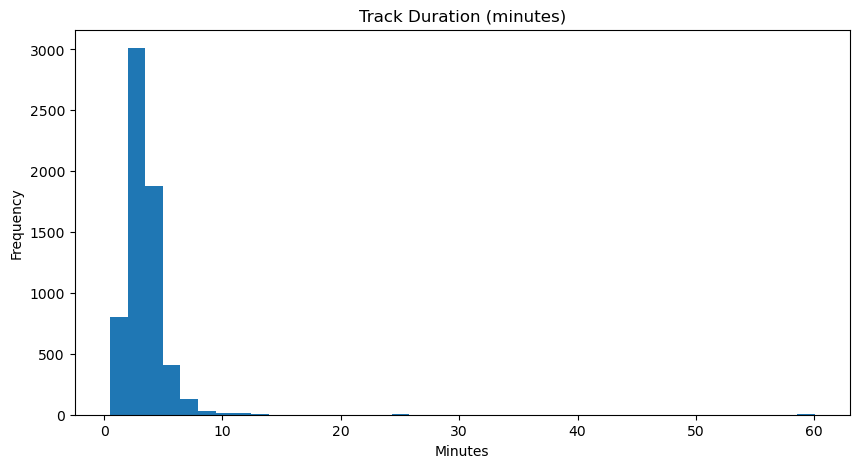

In [18]:
# Duration distribution
plt.hist(df2["duration_ms"]/60000, bins=40)
plt.title("Track Duration (minutes)")
plt.xlabel("Minutes")
plt.ylabel("Frequency")
plt.show()

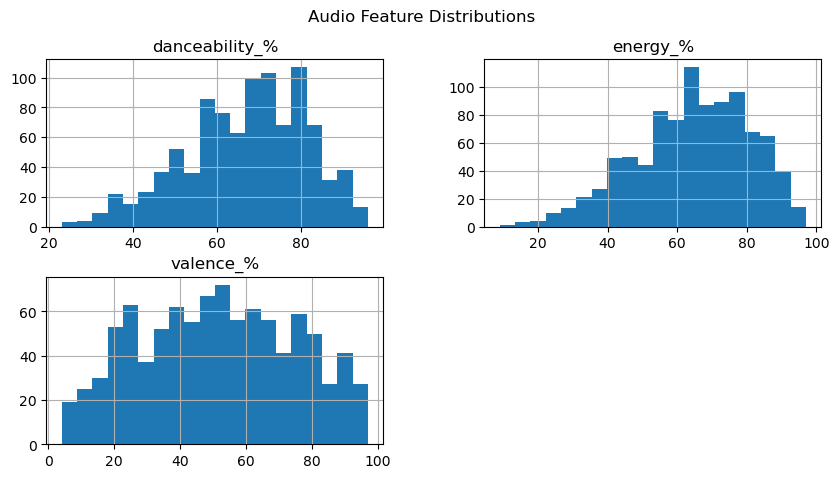

In [19]:
# Audio features (dataset1)
features = ["danceability_%","energy_%","valence_%"]

df1[features].hist(bins=20)
plt.suptitle("Audio Feature Distributions")
plt.show()